CAMPIONAMENTO E CATENE DI MARKOV: GESTIRE L'INTRATTABILITA'

Come facciamo a pescare un'idea da un cesto di probabilità infinite?
Saper descrivere un gatto non vuol dire saperlo disegnare.
La matematica esatta alza la bandiera bianca e dobbiamo affidarci alla simulazione stocastica

Ma quale muro invisibile ci sta ostacolando la strada?

A volte conosciamo una distribuzione di probabilità ma diventa troppo complesso quando le categorie aumentano.
Pensa ad un'immagine piccolissima di un solo pixel il solo pixel può assumere 256 valori, il numero di immagini (di un solo pixel) possibili sono pertanto 256.
Supponiamo che il modello sappia assegnare un peso ai dati, quindi conosce la struttura della distribuzione.
Per trasformare questi pesi in vere probabilità devi confrontare l'immagine con tutte le possibili immagini.
Con un'immagine, irrealistica, di un solo pixel potrebbe anche essere fattibile (256 possibilità) ma se l'immagine irrealistica diventa un piccola immagine 10x10 le possibilità esplodono 256x10x10=2560000, se poi pensiao ad un'immagine più grande le possibilità diventano incalcolabili.
Quindi conosciamo la regola matematica, ma applicarla esattamente richiederebbe una quantità irrealistica di calcoli.

Distribuzione semplice -> posso campionare direttamente
Distribuzione molto complessa -> campionamento diretto difficile o impossibile
    quindi:
    - costruisco una Catena di Markov
    - genero molti campioni
    - i campioni finiscono per seguire la stribuzione che mi interessa

Una catena di Markov è una sequenza X1, X2. X3, ..., Xn
con una particolarità: il prossimo stto dipende dal presente, non dall'intera storia precedente.
In altre parole: dove vado dopo, dipende da dove sono ora, non da tutta la strada che ho fatto.

Immagina il meteo, la previsione di domani dipende dal meteo di oggi, non dal meteo dall'inizio dell'anno, quindi ogni stato dipende solo da quello precedente.

Torniamo all'esempio delle pallino rosso, blu e vede
Rosso=60%
blu=30%
verde=10%
possiamo costruire una catena che si muove del tipo:
rosso -> blu
blu -> rosso
rosso -> verde
verde -> rosso
rosso -> blu
le probabilità di transizione vengono progettate in modo tale che, a lungo andare, la catena circa:
60% del tempo nel rosso
30% del tempo nel blu
10% del tempo nel verde
Questa cetena viene chiamata: distribuzione stazionaria.
Dopo in certo numero di passi (rosso, verde, rosso, blu, rosso, ecc) gli stati visitati possono essere considerati campioni della distribuzione desiderata.
Qui nasce il concetto di 
MCMC=Markov Chain Monte Carlo
MC=Markov Chain= ogni nuovo campione dipende dal precedente
MC=Monta Carlo= utilizziamo numeri casuali + molti campioni per effettuare stime numeriche
quindi
MCMC=Markov chain + Sampling casuale
l'obbiettivo è ottenere cmapioni da una distribuzione difficile da campionare direttamente

Invece di calcolare la probabilità analitica, estraiamo migliaia di campioni, la media di questi campioni, diventa la nostra verità. E' la potenza della statistica bruta che batte la complessità matematica.
Ma come facciamo ad estrasrre questi campioni?
entrano in gioco le catene di Markov

Matrice di Stazionarità
Il cammino verso l'equilibrio
Una catena di Markov ben costruita ha una meta invisibile, la distribuzione stazionaria.
L'ergodicità è la nostra garanzia, ci dice che non importa da dove partiamo, prima o poi visiteremo ogni angolo significativo, è il concetto di equilibrio in un sistema dinamico applicato ai dati
- La matrice di stazionarità definisce la probabilità di muoversi da uno punto x a un punto y nello spazio dei dati
- Una distribuzione stazionaria è quella che rimane invariata dopo una transazione della catena
- L'ergodicità garantisce che la catena possa visitar eogni stato possibile, indipendentemente dal punto di partenza.
- L'obbiettivo di MCMC è progettare una catena di Markov la cui distribuzione stazionaria coincida esattamente con la nostra distribuzione target.

Attenzione però che il cammino di un esploratore ha i suoi tempi

Dinamiche della Catena
Non tutti i passi della catena sono utili, anzi all'inizio l'esploratore, potrebbe essere partito da una cima deserta
Burn-in-Period: la fase iniziale in cui la catena si muove dal punto di partenza arbitrario verso le zone di alta probabilità; questi campioni iniziali vanno scartati
Inoltre, siccome i passi tendono ad essere vicini tra loro, i campioni tendono ad essere troppo simili
Autocorrelazione: campioni consecutivi in una catena sono correlati tra loro; spessi si effettua il 'thinning' prelevando un campione ogni k passi. Teniamo solo un passo ogni k passi.
E se l'esploratore è prigro? diciamo che il m ixing rate è basso. Una catena che esplora lentamente è un pericolo
Mixing Rate: la velocità con cui la catena esplora l'intera distribuzione; un mixing lento può portare a una visione parziale e distorta dei dati, della realtà

Ma questa simulazione è davvero affidabile come un calcolo essatto?

La risposta è si, grazie al Teorema del Limice Centrale per MCMC
Validità statistica del metodo
Anche se i nostri campioni sono legati uno all'altro, all'aumentare dei passi la loro media convergerà alla media reale della distribuzione.
E' un risusltato potente
Ci dice che possiamo sostituire la certezza in un integrale impossibile con la confidenza di una simulazione statistica.
Questo ci permette di  usare le simulazioni stocastiche con la stessa fiducia di un calcolo analitico.
Possiamo quindi fidarci del caos se è un caos regolato.

Vediamo come applicare tutto questo con degli algoritmo reali

Metodi di Campionamento Pratico
Rejection Sampling e Metropolis-Hastings
Passiamo all'implementazione
Come scegliamo effettivamente i punti?
Esistono metodi diretti (dove ogni lancio di dado conta) e metodi indiretti (basati su proposta ed accettazione).
Analizzeremo perchè il campionamento per rigetto fallisce in alta dimensione (troppo diffile) e come l'algoritmo di Metropolis-Hastings risolva questo problema, come un escursione guidata dove ogni passo viene valutato prima di essere compiuto

Analiziamo il meccanismo di questa valutazione

Accettazione e Rifiuto
Logiche di filtraggio dei campioni
- Il Rejection Sampling usa una distrinuzione proposta semplice che sovrasta la distribuzione target; i campioni sono accettati in base al rapporto tra le due
- Metropolis-Hastings propone un nuovo stato basandosi su quello attuale e lo accetta con una probabilità legata al miglioramento della verosomiglianza. Se il nuovo stato è migliore di quello attuale è accettato subito, se è peggiore non lo scariamo a priori, ma lanciamo una moneta per decidere se andarci comunque. Questo per non restare intrappolati in un piccolo buco ed ignorare il resto del mondo.
- Il Gibbs Sampling è un caso speciale di MH dove si campiona una variabile alla volta condizonata a tutte le altre
- Questi algoritmi permettono di campionare da distibuzioni di cui conosciamo solo la forma relativa, bypassando Z. Perfetto quando abbiamo moltissime variabili interconnesse

L'efficienza dipende tutto dalla nostra poposta

Efficienza del campionamento
Se proponiamo passo troppo lunghi inciampiamo sempre in zone impossibili o veniamo rifiutati
Una distribuzione proposta troppo stretta impedisce alla catena di esplorare nuovi picchi e ci mettiamo un'eternità ad arrivare a destinazione.
In alta dimensione tutto questo diventa un incubo, quasi ogni passo proposto finisce nel vuoto, ecco perchè dobbiamo diagnosticare la convergenza con strumenti come R-hat. Utilizzo di metriche come R-hat per verificare se catene diverse partite da punti diversi sono giunte alla stessa distribuzione.

Portiamo tutto questo sullo schero

Implementaizione e Visualizzazione
Metropolis-Hastings in azione




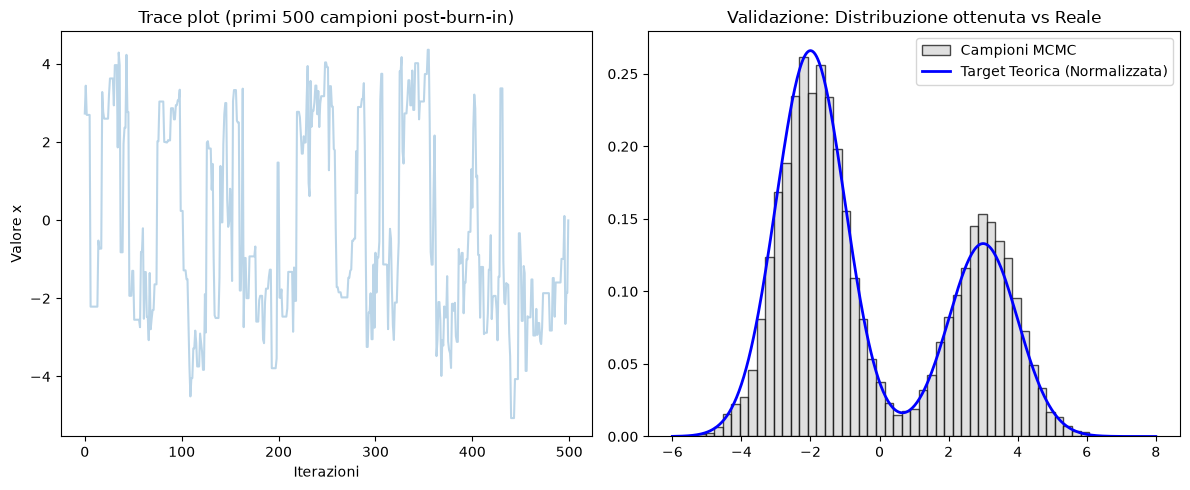

Miglior parametro k trovato: 0.511
Profitto totale massimo stimato: 36966.86


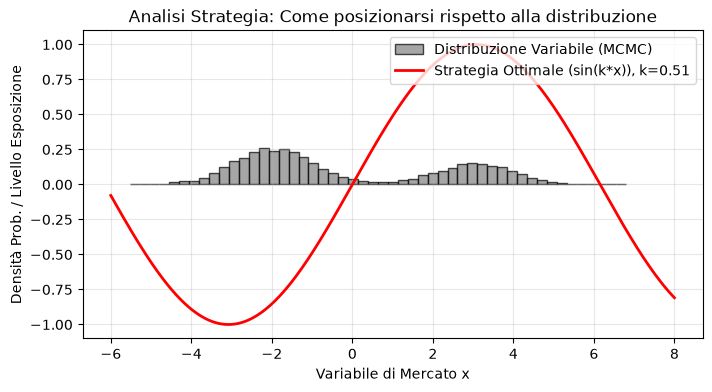

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================================================
# INTRODUZIONE TEORICA: CAMPIONAMENTO MCMC (MARKOV CHAIN MONTE CARLO)
# ==========================================================================================
# In molti problemi di statistica bayesiana e machine learning, ci troviamo a dover calcolare
# integrali complessi o aspettative su distribuzioni di probabilità p(x) che conosciamo 
# solo a meno di una costante di normalizzazione Z.
# Ovvero, sappiamo calcolare P*(x) tale che p(x) = P*(x) / Z, ma calcolare Z è intrattabile.
#
# L'algoritmo Metropolis-Hastings ci permette di generare campioni da p(x) usando solo P*(x).
#
# Qui sotto definiamo una "Target Density" P*(x) che è una mistura di due Gaussiane.
# Matematicamente: P*(x) ~ exp(-0.5(x+2)^2) + 0.5 * exp(-0.5(x-3)^2)
# Questa funzione non integra a 1, quindi non è una vera PDF (Probability Density Function),
# ma è proporzionale ad essa. L'algoritmo MCMC funzionerà comunque perfettamente.
# ==========================================================================================

# ------------------------------------------------------------
# 1. DEFINIZIONE DELLA DENSITÀ TARGET (PROBABILITÀ NON NORMALIZZATA)
# ------------------------------------------------------------
def target_density(x):
    """
    Calcola il valore proporzionale alla probabilità per un dato punto x.
    
    Teoria:
    Stiamo modellando un sistema bimodale (due picchi).
    - Il primo termine è un nocciolo gaussiano centrato in -2.
    - Il secondo termine è un nocciolo gaussiano centrato in +3, scalato di 0.5.
    
    Formula: P*(x) = e^{-0.5(x+2)^2} + 0.5 * e^{-0.5(x-3)^2}
    
    Nota: Non ci preoccupiamo di dividere per sqrt(2*pi) o altre costanti,
    perché nel rapporto di Metropolis le costanti moltiplicative si semplificano.
    """
    return torch.exp(-0.5 * (x + 2)**2) + 0.5 * torch.exp(-0.5 * (x - 3)**2)

# ------------------------------------------------------------
# 2. ALGORITMO METROPOLIS-HASTINGS
# ------------------------------------------------------------
def run_mcmc(iterations=5000, step_size=1.0):
    """
    Esegue l'algoritmo Metropolis-Hastings per generare campioni dalla target_density.
    
    Parametri:
    - iterations: numero di passi della catena di Markov.
    - step_size: deviazione standard del "passo" casuale (proposta).
    
    Teoria del Funzionamento:
    Costruiamo una Catena di Markov il cui stato stazionario è la distribuzione target.
    Ad ogni step 't', trovandoci nello stato x_t:
    1. Proponiamo un nuovo stato x' perturbando x_t con un rumore (es. Gaussiano).
       Q(x'|x_t) ~ N(x_t, step_size^2).
    2. Calcoliamo il rapporto di accettazione alpha = P*(x') / P*(x_t).
       - Se P*(x') > P*(x_t), il nuovo stato è più probabile: accettiamo sicuro (alpha >= 1).
       - Se P*(x') < P*(x_t), il nuovo stato è meno probabile: accettiamo con probabilità alpha.
         Questo permette alla catena di esplorare anche zone a bassa densità, evitando minimi locali.
    """
    samples = []
    
    # Inizializzazione arbitraria dello stato della catena (qui partiamo da 0.0)
    x = torch.tensor([0.0])
    
    for _ in range(iterations):
        # ---------------------------------------------------------
        # A. FASE DI PROPOSTA (PROPOSAL STEP)
        # ---------------------------------------------------------
        # Generiamo un candidato 'proposal' muovendoci da 'x' con un passo casuale.
        # Utilizziamo una distribuzione proposta Simmetrica (Random Walk Metropolis),
        # dove la probabilità di proporre x' partendo da x è uguale a quella di proporre x partendo da x'.
        # Questo semplifica la formula dell'accettazione (il termine Q(x|x')/Q(x'|x) diventa 1).
        proposal = x + torch.randn(1) * step_size

        # ---------------------------------------------------------
        # B. CALCOLO DELLE PROBABILITÀ (TARGET DENSITY)
        # ---------------------------------------------------------
        # Valutiamo quanto è "probabile" il punto corrente e quanto lo è il candidato.
        # Ricordiamo che questi valori non sono normalizzati.
        p_current   = target_density(x)
        p_proposal  = target_density(proposal)

        # ---------------------------------------------------------
        # C. CALCOLO DEL RAPPORTO DI ACCETTAZIONE (ALPHA)
        # ---------------------------------------------------------
        # Teoria: Alpha rappresenta la probabilità di accettare il nuovo stato.
        # Formula di Metropolis: alpha = min(1, P(x') / P(x))
        #
        # Perché funziona?
        # - Il rapporto p_proposal / p_current elimina la costante di normalizzazione Z incognita:
        #   (P*(x')/Z) / (P*(x)/Z) = P*(x') / P*(x).
        # - Questo meccanismo garantisce il rispetto del "Bilanciamento Dettagliato",
        #   condizione necessaria affinché la catena converga alla distribuzione target.
        ratio = p_proposal / p_current
        alpha = torch.min(torch.tensor(1.0), ratio)

        # ---------------------------------------------------------
        # D. DECISIONE DI ACCETTAZIONE/RIFIUTO
        # ---------------------------------------------------------
        # Generiamo un numero casuale uniforme u tra [0, 1].
        # Se u < alpha, accettiamo la mossa (x diventa proposal).
        # Altrimenti, rifiutiamo e rimaniamo nello stato corrente (x resta x).
        if torch.rand(1) < alpha:
            x = proposal
            # Se accettiamo, la catena si muove verso il nuovo punto.
        
        # NOTA IMPORTANTE: In MCMC, se rifiutiamo, aggiungiamo nuovamente
        # lo stato CORRENTE (quello vecchio) alla lista dei campioni.
        # Questo è fondamentale per preservare la corretta densità di probabilità temporale.
        samples.append(x.item())

    return np.array(samples)

# ==========================================================================================
# 3. ESECUZIONE DELLA SIMULAZIONE
# ==========================================================================================
# Generiamo 20.000 campioni. Un numero elevato è necessario per ridurre la varianza
# ("Monte Carlo Error") e approssimare bene la distribuzione vera.
samples = run_mcmc(iterations=20000, step_size=2.0)

# CONCETTO DI BURN-IN (RISCALDAMENTO):
# Le catene di Markov impiegano del tempo per "dimenticare" il punto di partenza arbitrario
# e raggiungere la zona di alta probabilità (convergenza alla distribuzione stazionaria).
# Scartiamo quindi i primi 2000 campioni per evitare bias dovuti all'inizializzazione.
burn_in = 2000
samples = samples[burn_in:]

# ==========================================================================================
# 4. VISUALIZZAZIONE E VALIDAZIONE
# ==========================================================================================
plt.figure(figsize=(12,5))

# Grafico 1: Trace Plot
# Serve a diagnosticare la convergenza. Se la catena si muove come un "bruco peloso"
# orizzontale senza trend evidenti, è segno di buon mescolamento (mixing).
plt.subplot(1,2,1)
plt.plot(samples[:500], alpha=0.3)
plt.title('Trace plot (primi 500 campioni post-burn-in)')
plt.xlabel('Iterazioni')
plt.ylabel('Valore x')

# Grafico 2: Istogramma vs Densità Teorica
# Confrontiamo la distribuzione empirica dei campioni (istogramma) con la formula matematica vera.
plt.subplot(1,2,2)
# density=True normalizza l'area dell'istogramma a 1, rendendolo una PDF empirica.
n, bins, _ = plt.hist(samples, bins=50, density=True,
                    color='lightgray', edgecolor='k', alpha=0.7, label='Campioni MCMC')

# Ricostruzione della curva teorica per confronto
x_grid = np.linspace(-6, 8, 400)
y_true = target_density(torch.tensor(x_grid)).numpy()

# NORMALIZZAZIONE NUMERICA DELLA TARGET DENSITY
# Poiché target_density(x) non integra a 1, dobbiamo calcolare l'area sottesa (Z)
# e dividere per essa per sovrapporla correttamente all'istogramma.
# Usiamo la regola del trapezio per approssimare l'integrale definito.
Z = np.trapezoid(y_true, x_grid)
plt.plot(x_grid, y_true/Z, 'b-', lw=2, label='Target Teorica (Normalizzata)')

plt.title('Validazione: Distribuzione ottenuta vs Reale')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================================================
# 5. APPLICAZIONE: OTTIMIZZAZIONE DI UNA STRATEGIA (EXPECTED UTILITY)
# ==========================================================================================
# Supponiamo ora che 'x' rappresenti una variabile di mercato (es. rendimento di un asset)
# di cui abbiamo stimato la distribuzione complessa tramite MCMC.
# Vogliamo testare una strategia di trading definita da una funzione parametrica.
#
# Strategia: Exposure(x) = sin(k * x)
# - k è un parametro da ottimizzare.
# - L'esposizione varia sinusoidalmente in base allo stato del mercato x.
#
# Profitto (PnL) = Exposure(x) * x
# - Se Exposure e x hanno lo stesso segno, guadagniamo.
# - Se hanno segno opposto, perdiamo.
#
# Obiettivo: Trovare k che massimizza il Valore Atteso del Profitto: E[PnL].
# Invece di calcolare un integrale analitico (impossibile), usiamo l'approssimazione Monte Carlo:
# E[f(x)] approx (1/N) * somma(f(x_i)) sui campioni generati.

k_vals = np.linspace(0.1, 4.0, 20) # Griglia di ricerca per il parametro k
best_k   = None
best_val = -np.inf # Inizializziamo con "meno infinito"

for k in k_vals:
    # Calcolo vettoriale su tutti i campioni simultaneamente
    exposure = np.sin(k * samples)          # Posizione della strategia per ogni scenario
    pnl      = exposure * samples           # Profitto/Perdita per ogni scenario
    
    # La somma dei PnL è proporzionale al valore atteso (media).
    # Massimizzare la somma equivale a massimizzare l'aspettativa.
    val      = pnl.sum()
    
    # Logic "Greedy" per aggiornare il miglior risultato trovato finora
    if val > best_val:
        best_val = val
        best_k   = k

print(f"Miglior parametro k trovato: {best_k:.3f}")
print(f"Profitto totale massimo stimato: {best_val:.2f}")

# ==========================================================================================
# 6. VISUALIZZAZIONE DELLA STRATEGIA OTTIMALE
# ==========================================================================================
plt.figure(figsize=(8,4))

# Mostriamo di nuovo la distribuzione del mercato (i rischi/opportunità)
plt.hist(samples, bins=50, density=True,
         color='gray', edgecolor='k', alpha=0.7, label='Distribuzione Variabile (MCMC)')

# Sovrapponiamo la funzione di "Esposizione" ottimale
# Nota: La sinusoide non è una densità di probabilità, è una funzione di reazione (Policy).
# La mostriamo sullo stesso asse per vedere come reagisce alle zone di alta densità.
x_plot = np.linspace(-6, 8, 400)
plt.plot(x_plot, np.sin(best_k * x_plot), 'r-', lw=2,
         label=f'Strategia Ottimale (sin(k*x)), k={best_k:.2f}')

plt.title('Analisi Strategia: Come posizionarsi rispetto alla distribuzione')
plt.xlabel('Variabile di Mercato x')
plt.ylabel('Densità Prob. / Livello Esposizione')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()
